# Image Similarity Retrieval Test: DINOv2 vs Qwen3-VL-Embedding

This notebook compares two image embedding models for template retrieval on local document files:
- **facebook/dinov2-giant**: Pure image embedding model
- **Qwen/Qwen3-VL-Embedding-2B**: Multimodal embedding model

Test setup:
- Index template pages from local files in `templates/`
- Use local files in `test/` as query inputs
- Render PDF pages to images before embedding
- Store template embeddings in ChromaDB with separate collections
- Compare top-k retrieved template pages for each query page

## 1. Import Required Libraries

In [2]:
import numpy as np
import torch
import chromadb
from chromadb.config import Settings
import os
import time
from PIL import Image
import pypdfium2 as pdfium
import requests
from io import BytesIO
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from typing import Dict, List, Tuple, Any
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create data directories
data_dir = Path('chroma_layout_db')
dinov2_dir = data_dir / 'dinov2_collection'
qwen_dir = data_dir / 'qwen_collection'
dinov2_dir.mkdir(parents=True, exist_ok=True)
qwen_dir.mkdir(parents=True, exist_ok=True)

Using device: cuda


## 2. Load and Initialize Both Models

In [3]:
from transformers import AutoImageProcessor, AutoModel

print("=" * 50)
print("Loading DINOv2 Model...")
print("=" * 50)
try:
    dinov2_processor = AutoImageProcessor.from_pretrained('facebook/dinov2-giant')
    dinov2_model = AutoModel.from_pretrained('facebook/dinov2-giant').to(device)
    dinov2_model.eval()
    print("✓ DINOv2 model loaded successfully!")
    print(f"  - Model type: Vision Transformer (ViT)")
    print(f"  - Embedding dimension: 1536")
except Exception as e:
    print(f"✗ Error loading DINOv2: {e}")
    dinov2_model = None
    dinov2_processor = None

print("\n" + "=" * 50)
print("Loading Qwen3-VL-Embedding Model...")
print("=" * 50)
try:
    from sentence_transformers import SentenceTransformer
    qwen_model = SentenceTransformer('Qwen/Qwen3-VL-Embedding-2B')
    print("✓ Qwen3-VL-Embedding model loaded successfully!")
    print(f"  - Model type: Multimodal Embedding")
    print(f"  - Embedding dimension: 2048")
except Exception as e:
    print(f"✗ Error loading Qwen3-VL-Embedding: {e}")
    qwen_model = None

print("\n" + "=" * 50)

Loading DINOv2 Model...


Loading weights: 100%|██████████| 727/727 [00:00<00:00, 2113.06it/s]


✓ DINOv2 model loaded successfully!
  - Model type: Vision Transformer (ViT)
  - Embedding dimension: 1536

Loading Qwen3-VL-Embedding Model...


Loading weights: 100%|██████████| 625/625 [00:00<00:00, 2776.79it/s]
Default prompt name is set to 'default'. This prompt will be applied to all inference calls, except if a `prompt` or `prompt_name` parameter is provided.


✓ Qwen3-VL-Embedding model loaded successfully!
  - Model type: Multimodal Embedding
  - Embedding dimension: 2048



## 3. Create ChromaDB Collections for Template Retrieval

In [4]:
# Initialize ChromaDB clients with persistent storage
print("Initializing ChromaDB clients...")

# DINOv2 Collection
dinov2_client = chromadb.PersistentClient(
    path=str(dinov2_dir),
    settings=Settings(
        allow_reset=True,
        anonymized_telemetry=False,
        is_persistent=True
    )
)

# Qwen Collection
qwen_client = chromadb.PersistentClient(
    path=str(qwen_dir),
    settings=Settings(
        allow_reset=True,
        anonymized_telemetry=False,
        is_persistent=True
    )
)

# Create collections with cosine distance
print("\nCreating collections with cosine distance...")

# Delete existing collections if they exist
try:
    dinov2_client.delete_collection(name="dinov2_images")
    print("✓ Deleted existing DINOv2 collection")
except:
    pass

try:
    qwen_client.delete_collection(name="qwen_images")
    print("✓ Deleted existing Qwen collection")
except:
    pass

# Create new collections
dinov2_collection = dinov2_client.create_collection(
    name="dinov2_images",
    metadata={"hnsw:space": "cosine"}
)

qwen_collection = qwen_client.create_collection(
    name="qwen_images",
    metadata={"hnsw:space": "cosine"}
)

print("✓ DINOv2 template collection created")
print("✓ Qwen template collection created")

Initializing ChromaDB clients...

Creating collections with cosine distance...
✓ Deleted existing DINOv2 collection
✓ Deleted existing Qwen collection
✓ DINOv2 template collection created
✓ Qwen template collection created


## 4. Load Local Template and Query Documents

In [5]:
# Load template files and query files from local folders
template_dir = Path("templates")
query_dir = Path("test")
supported_extensions = {".pdf", ".png", ".jpg", ".jpeg", ".tiff", ".bmp", ".gif", ".webp"}

def render_pdf_pages(pdf_path: Path, scale: float = 2.0) -> List[Image.Image]:
    """Render all pages in a PDF file to PIL images."""
    document = pdfium.PdfDocument(str(pdf_path))
    return [page.render(scale=scale).to_pil().convert("RGB") for page in document]

def load_document_pages(file_path: Path) -> List[Image.Image]:
    """Load a document as one or more PIL images."""
    suffix = file_path.suffix.lower()
    if suffix == ".pdf":
        return render_pdf_pages(file_path)
    if suffix in supported_extensions:
        return [Image.open(file_path).convert("RGB")]
    raise ValueError(f"Unsupported file type: {file_path}")

def build_image_records(folder: Path, source_type: str) -> List[Dict[str, Any]]:
    """Build per-page image records from a folder of PDFs and images."""
    records: List[Dict[str, Any]] = []
    files = sorted(
        file_path for file_path in folder.iterdir()
        if file_path.is_file() and file_path.suffix.lower() in supported_extensions
    )

    for file_path in files:
        pages = load_document_pages(file_path)
        for page_number, image in enumerate(pages, start=1):
            page_suffix = f"_page_{page_number}" if len(pages) > 1 else ""
            record_id = f"{source_type}_{file_path.stem}{page_suffix}"
            records.append({
                "id": record_id,
                "name": f"{file_path.name}{page_suffix}",
                "image": image,
                "description": f"{source_type.title()} file {file_path.name}, page {page_number}",
                "file_name": file_path.name,
                "file_path": str(file_path),
                "page_number": page_number,
                "source_type": source_type,
            })
            print(f"✓ Loaded {source_type}: {file_path.name} (page {page_number})")

    return records

print("Loading template files...")
template_records = build_image_records(template_dir, "template")
print(f"\nTotal template pages loaded: {len(template_records)}")

print("\nLoading query files...")
query_records = build_image_records(query_dir, "query")
print(f"\nTotal query pages loaded: {len(query_records)}")

if not template_records:
    raise RuntimeError("No template pages found in templates/.")

if not query_records:
    raise RuntimeError("No query files found in test/.")

Loading template files...
✓ Loaded template: CoO UN template.png (page 1)
✓ Loaded template: CoO WCO (kyoto).png (page 1)
✓ Loaded template: Egypt- CoO Templates.pdf (page 1)
✓ Loaded template: Egypt- CoO Templates.pdf (page 2)
✓ Loaded template: Egypt- CoO Templates.pdf (page 3)
✓ Loaded template: Egypt- CoO Templates.pdf (page 4)
✓ Loaded template: Egypt- CoO Templates.pdf (page 5)
✓ Loaded template: Egypt- CoO Templates.pdf (page 6)
✓ Loaded template: Egypt- CoO Templates.pdf (page 7)
✓ Loaded template: Egypt- CoO Templates.pdf (page 8)
✓ Loaded template: Egypt- CoO Templates.pdf (page 9)
✓ Loaded template: Egypt- CoO Templates.pdf (page 10)

Total template pages loaded: 12

Loading query files...
✓ Loaded query: image copy2.png (page 1)
✓ Loaded query: image.png (page 1)
✓ Loaded query: image1.png (page 1)

Total query pages loaded: 3


In [6]:
# Embed template pages with DINOv2
print("\n" + "=" * 50)
print("Embedding template pages with DINOv2...")
print("=" * 50)

dinov2_embeddings = {}
if dinov2_model is not None:
    with torch.no_grad():
        for record in template_records:
            try:
                inputs = dinov2_processor(images=record["image"], return_tensors="pt").to(device)
                outputs = dinov2_model(**inputs)
                embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy().flatten()
                dinov2_embeddings[record["id"]] = embedding
                print(f"✓ Embedded template: {record['name']} (shape: {embedding.shape})")
            except Exception as e:
                print(f"✗ Error embedding template {record['name']}: {e}")

print(f"\nTotal DINOv2 template embeddings: {len(dinov2_embeddings)}")

# Embed template pages with Qwen3-VL-Embedding
print("\n" + "=" * 50)
print("Embedding template pages with Qwen3-VL-Embedding...")
print("=" * 50)

qwen_embeddings = {}
if qwen_model is not None:
    for record in template_records:
        try:
            embedding = qwen_model.encode(record["image"])
            qwen_embeddings[record["id"]] = embedding
            print(f"✓ Embedded template: {record['name']} (shape: {embedding.shape})")
        except Exception as e:
            print(f"✗ Error embedding template {record['name']}: {e}")

print(f"\nTotal Qwen template embeddings: {len(qwen_embeddings)}")


Embedding template pages with DINOv2...
✓ Embedded template: CoO UN template.png (shape: (1536,))
✓ Embedded template: CoO WCO (kyoto).png (shape: (1536,))
✓ Embedded template: Egypt- CoO Templates.pdf_page_1 (shape: (1536,))
✓ Embedded template: Egypt- CoO Templates.pdf_page_2 (shape: (1536,))
✓ Embedded template: Egypt- CoO Templates.pdf_page_3 (shape: (1536,))
✓ Embedded template: Egypt- CoO Templates.pdf_page_4 (shape: (1536,))
✓ Embedded template: Egypt- CoO Templates.pdf_page_5 (shape: (1536,))
✓ Embedded template: Egypt- CoO Templates.pdf_page_6 (shape: (1536,))
✓ Embedded template: Egypt- CoO Templates.pdf_page_7 (shape: (1536,))
✓ Embedded template: Egypt- CoO Templates.pdf_page_8 (shape: (1536,))
✓ Embedded template: Egypt- CoO Templates.pdf_page_9 (shape: (1536,))
✓ Embedded template: Egypt- CoO Templates.pdf_page_10 (shape: (1536,))

Total DINOv2 template embeddings: 12

Embedding template pages with Qwen3-VL-Embedding...
✓ Embedded template: CoO UN template.png (shape: (2

In [7]:
# Store template embeddings in ChromaDB collections
print("\n" + "=" * 50)
print("Storing template embeddings in ChromaDB...")
print("=" * 50)

template_record_map = {record["id"]: record for record in template_records}

# Store DINOv2 embeddings
print("\nStoring DINOv2 template embeddings...")
for record_id, embedding in dinov2_embeddings.items():
    record = template_record_map[record_id]
    dinov2_collection.add(
        embeddings=[embedding.tolist()],
        metadatas=[{
            "name": record["name"],
            "description": record["description"],
            "file_name": record["file_name"],
            "page_number": record["page_number"],
            "source_type": record["source_type"],
            "model": "dinov2-giant",
            "file_path": record["file_path"],
        }],
        ids=[record_id]
    )
    print(f"✓ Stored template: {record['name']}")

print(f"DINOv2 collection size: {dinov2_collection.count()}")

# Store Qwen embeddings
print("\nStoring Qwen template embeddings...")
for record_id, embedding in qwen_embeddings.items():
    record = template_record_map[record_id]
    qwen_collection.add(
        embeddings=[embedding.tolist()],
        metadatas=[{
            "name": record["name"],
            "description": record["description"],
            "file_name": record["file_name"],
            "page_number": record["page_number"],
            "source_type": record["source_type"],
            "model": "qwen3-vl-embedding-2b",
            "file_path": record["file_path"],
        }],
        ids=[record_id]
    )
    print(f"✓ Stored template: {record['name']}")

print(f"Qwen collection size: {qwen_collection.count()}")


Storing template embeddings in ChromaDB...

Storing DINOv2 template embeddings...
✓ Stored template: CoO UN template.png
✓ Stored template: CoO WCO (kyoto).png
✓ Stored template: Egypt- CoO Templates.pdf_page_1
✓ Stored template: Egypt- CoO Templates.pdf_page_2
✓ Stored template: Egypt- CoO Templates.pdf_page_3
✓ Stored template: Egypt- CoO Templates.pdf_page_4
✓ Stored template: Egypt- CoO Templates.pdf_page_5
✓ Stored template: Egypt- CoO Templates.pdf_page_6
✓ Stored template: Egypt- CoO Templates.pdf_page_7
✓ Stored template: Egypt- CoO Templates.pdf_page_8
✓ Stored template: Egypt- CoO Templates.pdf_page_9
✓ Stored template: Egypt- CoO Templates.pdf_page_10
DINOv2 collection size: 12

Storing Qwen template embeddings...
✓ Stored template: CoO UN template.png
✓ Stored template: CoO WCO (kyoto).png
✓ Stored template: Egypt- CoO Templates.pdf_page_1
✓ Stored template: Egypt- CoO Templates.pdf_page_2
✓ Stored template: Egypt- CoO Templates.pdf_page_3
✓ Stored template: Egypt- CoO Tem

## 5. Define Top-2 Template Retrieval Functions

In [8]:
def query_dinov2(query_image: Image.Image, top_k: int = 2) -> Dict[str, Any]:
    """Query the template collection with a single query image using DINOv2."""
    if dinov2_model is None:
        return {}

    with torch.no_grad():
        inputs = dinov2_processor(images=query_image, return_tensors="pt").to(device)
        outputs = dinov2_model(**inputs)
        query_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy().flatten()

    results = dinov2_collection.query(
        query_embeddings=[query_embedding.tolist()],
        n_results=min(top_k, dinov2_collection.count())
    )

    return {
        "model": "DINOv2",
        "query_embedding_shape": query_embedding.shape,
        "results": results,
    }

def query_qwen(query_image: Image.Image, top_k: int = 2) -> Dict[str, Any]:
    """Query the template collection with a single query image using Qwen3-VL-Embedding."""
    if qwen_model is None:
        return {}

    query_embedding = qwen_model.encode(query_image)

    results = qwen_collection.query(
        query_embeddings=[query_embedding.tolist()],
        n_results=min(top_k, qwen_collection.count())
    )

    return {
        "model": "Qwen3-VL-Embedding",
        "query_embedding_shape": query_embedding.shape,
        "results": results,
    }

def format_result_label(doc: Dict[str, Any]) -> str:
    """Format template metadata for display."""
    return f"{doc['file_name']} (page {doc['page_number']})"

def show_top2_results(query_record: Dict[str, Any], result_bundle: Dict[str, Any], title: str) -> None:
    """Display the query page and top-2 retrieved template pages."""
    result_ids = result_bundle["results"]["ids"][0] if result_bundle["results"]["ids"] else []
    result_docs = result_bundle["results"]["metadatas"][0] if result_bundle["results"]["metadatas"] else []
    result_distances = result_bundle["results"]["distances"][0] if result_bundle["results"]["distances"] else []

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    axes[0].imshow(query_record["image"])
    axes[0].set_title(f"Query\n{query_record['file_name']}\npage {query_record['page_number']}")
    axes[0].axis('off')

    for index in range(2):
        ax = axes[index + 1]
        if index < len(result_ids):
            record = template_record_map[result_ids[index]]
            similarity = 1 - result_distances[index]
            ax.imshow(record["image"])
            ax.set_title(
                f"Top {index + 1}\n{record['file_name']}\npage {record['page_number']}\nsim: {similarity:.4f}"
            )
        else:
            ax.text(0.5, 0.5, 'No result', ha='center', va='center')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

def format_query_results(dinov2_results: Dict[str, Any], qwen_results: Dict[str, Any]) -> None:
    """Print top retrieved template pages for both models."""
    print("\n" + "=" * 120)
    print("TOP-2 RETRIEVAL RESULTS")
    print("=" * 120)

    print(f"\n{'DINOv2 (Image-Only)':<60} | {'Qwen3-VL-Embedding (Multimodal)':<60}")
    print("-" * 120)

    dinov2_docs = dinov2_results["results"]["metadatas"][0] if dinov2_results["results"]["metadatas"] else []
    dinov2_distances = dinov2_results["results"]["distances"][0] if dinov2_results["results"]["distances"] else []

    qwen_docs = qwen_results["results"]["metadatas"][0] if qwen_results["results"]["metadatas"] else []
    qwen_distances = qwen_results["results"]["distances"][0] if qwen_results["results"]["distances"] else []

    max_results = max(len(dinov2_docs), len(qwen_docs))

    for i in range(max_results):
        dinov2_line = ""
        qwen_line = ""

        if i < len(dinov2_docs):
            doc = dinov2_docs[i]
            similarity = 1 - dinov2_distances[i]
            dinov2_line = f"{i+1}. {format_result_label(doc):<42} (sim: {similarity:.4f})"

        if i < len(qwen_docs):
            doc = qwen_docs[i]
            similarity = 1 - qwen_distances[i]
            qwen_line = f"{i+1}. {format_result_label(doc):<42} (sim: {similarity:.4f})"

        print(f"{dinov2_line:<60} | {qwen_line:<60}")

## 6. Run Retrieval on Test Folder and Show Top-2 Results


RUNNING TOP-2 TEMPLATE RETRIEVAL TESTS


####################################################################################################
Query File: image copy.png
Query Page: 1
Description: Query file image copy.png, page 1
####################################################################################################

TOP-2 RETRIEVAL RESULTS

DINOv2 (Image-Only)                                          | Qwen3-VL-Embedding (Multimodal)                             
------------------------------------------------------------------------------------------------------------------------
1. Egypt- CoO Templates.pdf (page 6)          (sim: 0.7332)  | 1. Egypt- CoO Templates.pdf (page 6)          (sim: 0.6985) 
2. Egypt- CoO Templates.pdf (page 8)          (sim: 0.7165)  | 2. Egypt- CoO Templates.pdf (page 5)          (sim: 0.6920) 


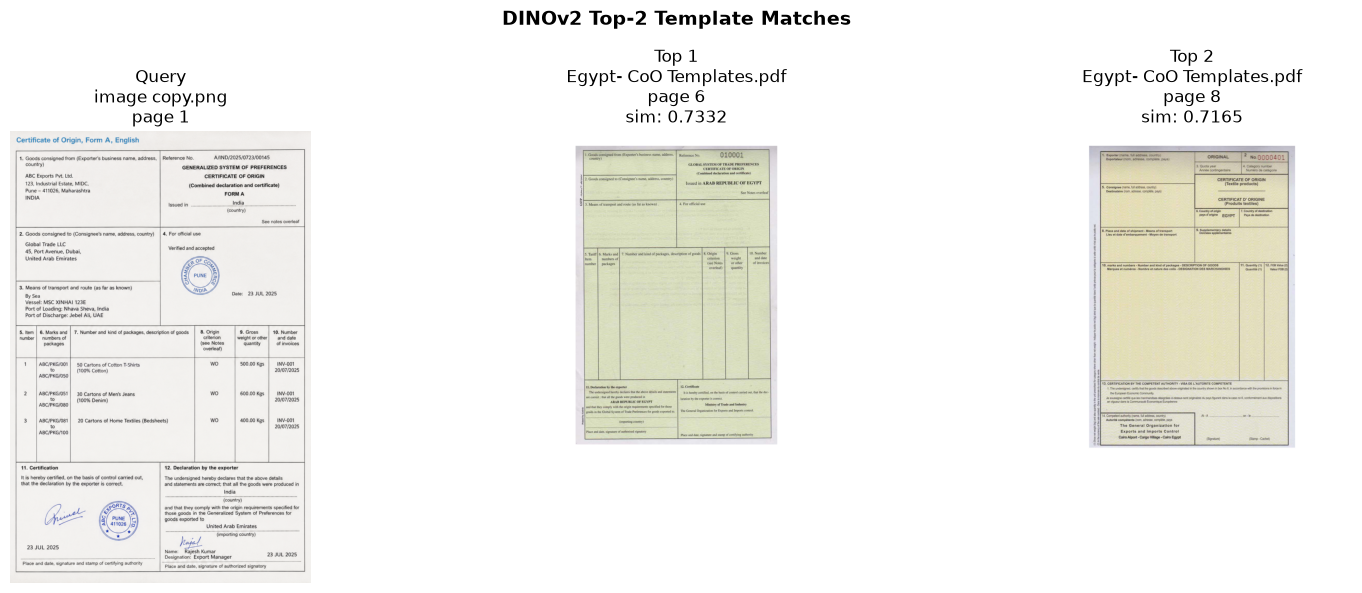

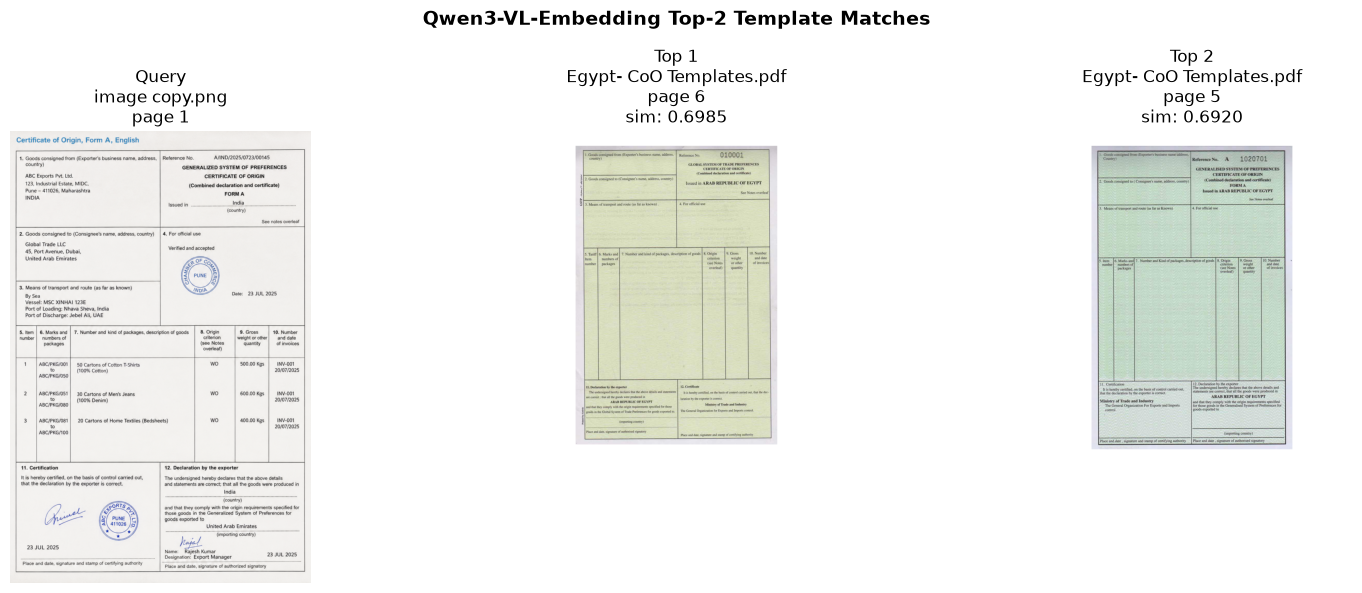



####################################################################################################
Query File: image.png
Query Page: 1
Description: Query file image.png, page 1
####################################################################################################

TOP-2 RETRIEVAL RESULTS

DINOv2 (Image-Only)                                          | Qwen3-VL-Embedding (Multimodal)                             
------------------------------------------------------------------------------------------------------------------------
1. Egypt- CoO Templates.pdf (page 10)         (sim: 0.7421)  | 1. Egypt- CoO Templates.pdf (page 5)          (sim: 0.6998) 
2. Egypt- CoO Templates.pdf (page 9)          (sim: 0.7259)  | 2. Egypt- CoO Templates.pdf (page 6)          (sim: 0.6945) 


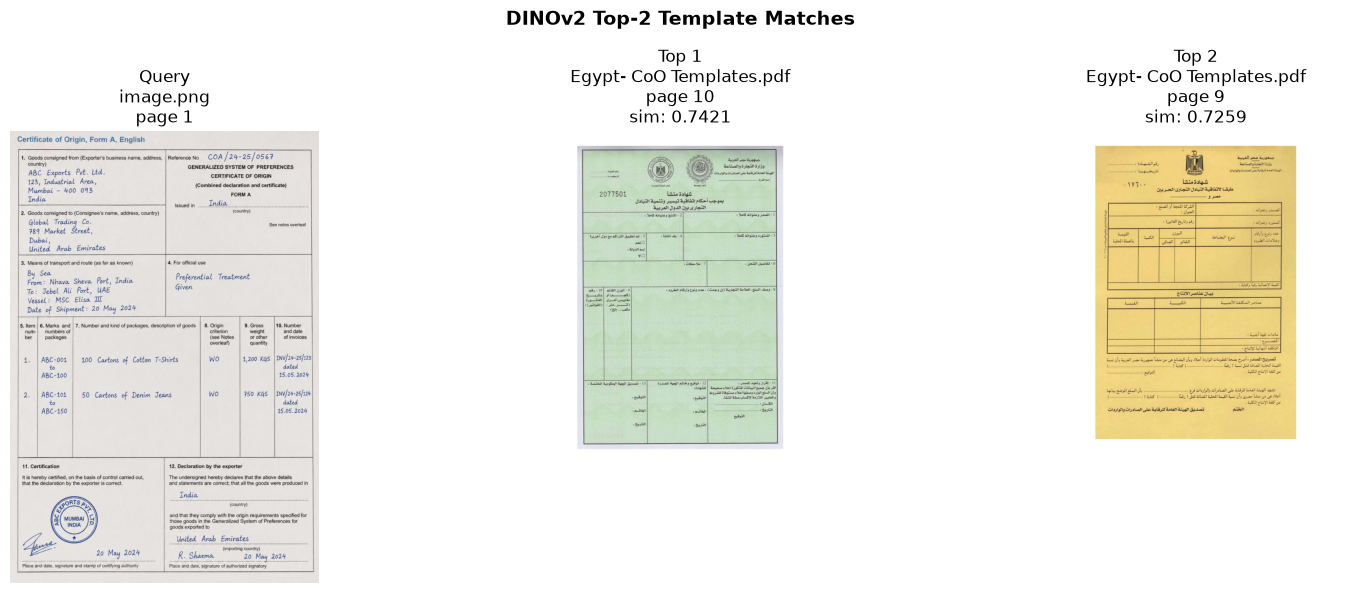

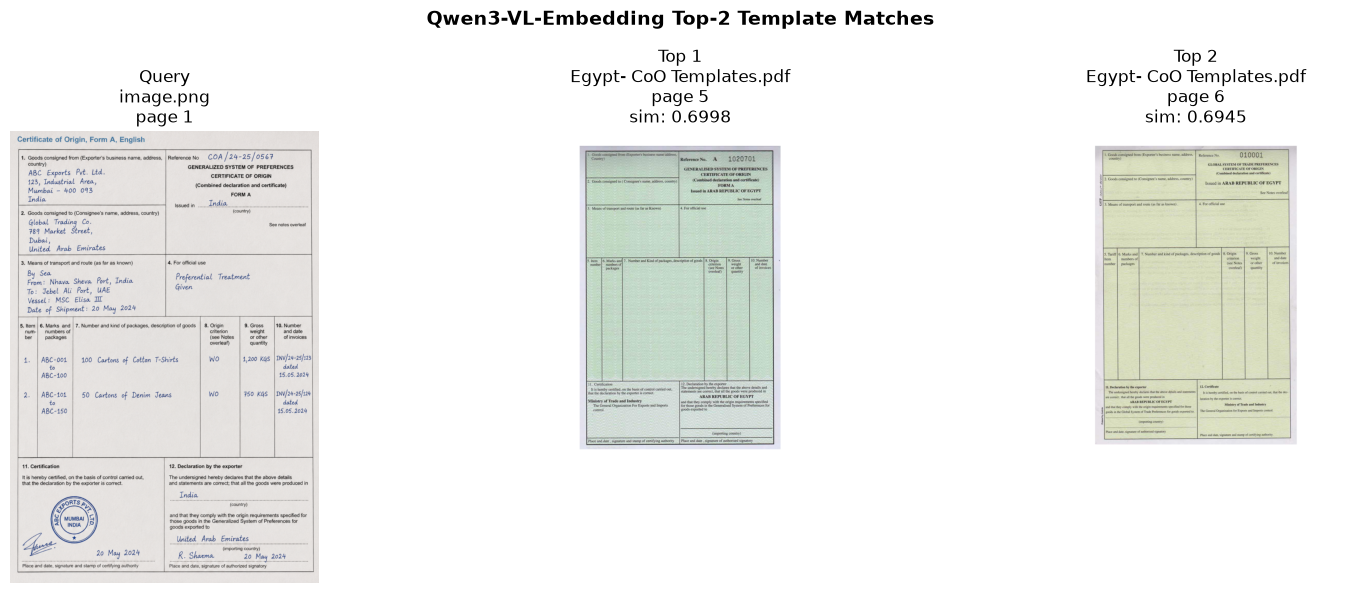

In [39]:
# Use test/ as query inputs and show top-2 template matches for each query page
print("\n" + "=" * 100)
print("RUNNING TOP-2 TEMPLATE RETRIEVAL TESTS")
print("=" * 100)

test_results = {}
top_k = min(2, len(template_records))

for query_record in query_records:
    query_id = query_record["id"]
    print(f"\n\n{'#' * 100}")
    print(f"Query File: {query_record['file_name']}")
    print(f"Query Page: {query_record['page_number']}")
    print(f"Description: {query_record['description']}")
    print(f"{'#' * 100}")

    dinov2_results = query_dinov2(query_record["image"], top_k=top_k)
    qwen_results = query_qwen(query_record["image"], top_k=top_k)

    format_query_results(dinov2_results, qwen_results)
    show_top2_results(query_record, dinov2_results, "DINOv2 Top-2 Template Matches")
    show_top2_results(query_record, qwen_results, "Qwen3-VL-Embedding Top-2 Template Matches")

    test_results[query_id] = {
        "query": query_record,
        "dinov2": dinov2_results,
        "qwen": qwen_results,
    }

## 7. Evaluate Top-2 Retrieval Metrics

In [32]:
# Calculate retrieval summary metrics for top-2 results
print("\n" + "=" * 100)
print("TOP-2 RETRIEVAL QUALITY METRICS")
print("=" * 100)

def calculate_metrics(test_results: Dict[str, Any]) -> Dict[str, Any]:
    """Calculate summary retrieval metrics for top-2 template matching."""
    metrics = {
        "dinov2": {
            "mean_top1_similarity": 0.0,
            "mean_top2_similarity": 0.0,
            "mean_similarity_spread": 0.0,
        },
        "qwen": {
            "mean_top1_similarity": 0.0,
            "mean_top2_similarity": 0.0,
            "mean_similarity_spread": 0.0,
        },
        "top1_agreement_count": 0,
    }

    dinov2_top1_sims = []
    dinov2_top2_sims = []
    dinov2_spreads = []
    qwen_top1_sims = []
    qwen_top2_sims = []
    qwen_spreads = []

    for result in test_results.values():
        dinov2_dists = result["dinov2"]["results"]["distances"][0]
        qwen_dists = result["qwen"]["results"]["distances"][0]

        dinov2_sims = [1 - d for d in dinov2_dists]
        qwen_sims = [1 - d for d in qwen_dists]

        dinov2_top1_sims.append(dinov2_sims[0])
        dinov2_top2_sims.append(float(np.mean(dinov2_sims[:2])))
        dinov2_spreads.append(float(np.std(dinov2_sims)) if len(dinov2_sims) > 1 else 0.0)

        qwen_top1_sims.append(qwen_sims[0])
        qwen_top2_sims.append(float(np.mean(qwen_sims[:2])))
        qwen_spreads.append(float(np.std(qwen_sims)) if len(qwen_sims) > 1 else 0.0)

        dinov2_top_doc = result["dinov2"]["results"]["metadatas"][0][0]
        qwen_top_doc = result["qwen"]["results"]["metadatas"][0][0]
        dinov2_top_label = format_result_label(dinov2_top_doc)
        qwen_top_label = format_result_label(qwen_top_doc)
        if dinov2_top_label == qwen_top_label:
            metrics["top1_agreement_count"] += 1

    metrics["dinov2"]["mean_top1_similarity"] = float(np.mean(dinov2_top1_sims))
    metrics["dinov2"]["mean_top2_similarity"] = float(np.mean(dinov2_top2_sims))
    metrics["dinov2"]["mean_similarity_spread"] = float(np.mean(dinov2_spreads))

    metrics["qwen"]["mean_top1_similarity"] = float(np.mean(qwen_top1_sims))
    metrics["qwen"]["mean_top2_similarity"] = float(np.mean(qwen_top2_sims))
    metrics["qwen"]["mean_similarity_spread"] = float(np.mean(qwen_spreads))

    return metrics

metrics = calculate_metrics(test_results)
num_queries = len(test_results)

print("\n" + "-" * 100)
print("DINOV2 METRICS")
print("-" * 100)
print(f"Mean Top-1 Similarity:     {metrics['dinov2']['mean_top1_similarity']:.6f}")
print(f"Mean Top-2 Similarity:     {metrics['dinov2']['mean_top2_similarity']:.6f}")
print(f"Mean Similarity Spread:    {metrics['dinov2']['mean_similarity_spread']:.6f}")

print("\n" + "-" * 100)
print("QWEN3-VL-EMBEDDING METRICS")
print("-" * 100)
print(f"Mean Top-1 Similarity:     {metrics['qwen']['mean_top1_similarity']:.6f}")
print(f"Mean Top-2 Similarity:     {metrics['qwen']['mean_top2_similarity']:.6f}")
print(f"Mean Similarity Spread:    {metrics['qwen']['mean_similarity_spread']:.6f}")

print("\n" + "=" * 100)
print("COMPARATIVE ANALYSIS")
print("=" * 100)
dinov2_top1_better = "✓ BETTER" if metrics['dinov2']['mean_top1_similarity'] > metrics['qwen']['mean_top1_similarity'] else "✗ WORSE"
qwen_top1_better = "✓ BETTER" if metrics['qwen']['mean_top1_similarity'] > metrics['dinov2']['mean_top1_similarity'] else "✗ WORSE"

print(f"\nTop-1 Similarity Comparison:")
print(f"  DINOv2:       {metrics['dinov2']['mean_top1_similarity']:.6f} {dinov2_top1_better}")
print(f"  Qwen3-VL:     {metrics['qwen']['mean_top1_similarity']:.6f} {qwen_top1_better}")
print(f"  Difference:   {abs(metrics['dinov2']['mean_top1_similarity'] - metrics['qwen']['mean_top1_similarity']):.6f}")

print("\nTop-2 Average Similarity Comparison:")
print(f"  DINOv2:       {metrics['dinov2']['mean_top2_similarity']:.6f}")
print(f"  Qwen3-VL:     {metrics['qwen']['mean_top2_similarity']:.6f}")
print(f"  Difference:   {abs(metrics['dinov2']['mean_top2_similarity'] - metrics['qwen']['mean_top2_similarity']):.6f}")

print(f"\nRetrieval Discriminability (Similarity Spread):")
print(f"  DINOv2:       {metrics['dinov2']['mean_similarity_spread']:.6f}")
print(f"  Qwen3-VL:     {metrics['qwen']['mean_similarity_spread']:.6f}")

print(f"\nTop-1 Template Agreement: {metrics['top1_agreement_count']}/{num_queries}")


TOP-2 RETRIEVAL QUALITY METRICS

----------------------------------------------------------------------------------------------------
DINOV2 METRICS
----------------------------------------------------------------------------------------------------
Mean Top-1 Similarity:     0.653888
Mean Top-2 Similarity:     0.633834
Mean Similarity Spread:    0.020055

----------------------------------------------------------------------------------------------------
QWEN3-VL-EMBEDDING METRICS
----------------------------------------------------------------------------------------------------
Mean Top-1 Similarity:     0.603575
Mean Top-2 Similarity:     0.586374
Mean Similarity Spread:    0.017202

COMPARATIVE ANALYSIS

Top-1 Similarity Comparison:
  DINOv2:       0.653888 ✓ BETTER
  Qwen3-VL:     0.603575 ✗ WORSE
  Difference:   0.050313

Top-2 Average Similarity Comparison:
  DINOv2:       0.633834
  Qwen3-VL:     0.586374
  Difference:   0.047460

Retrieval Discriminability (Similarity Spread

### Visualization of Metrics

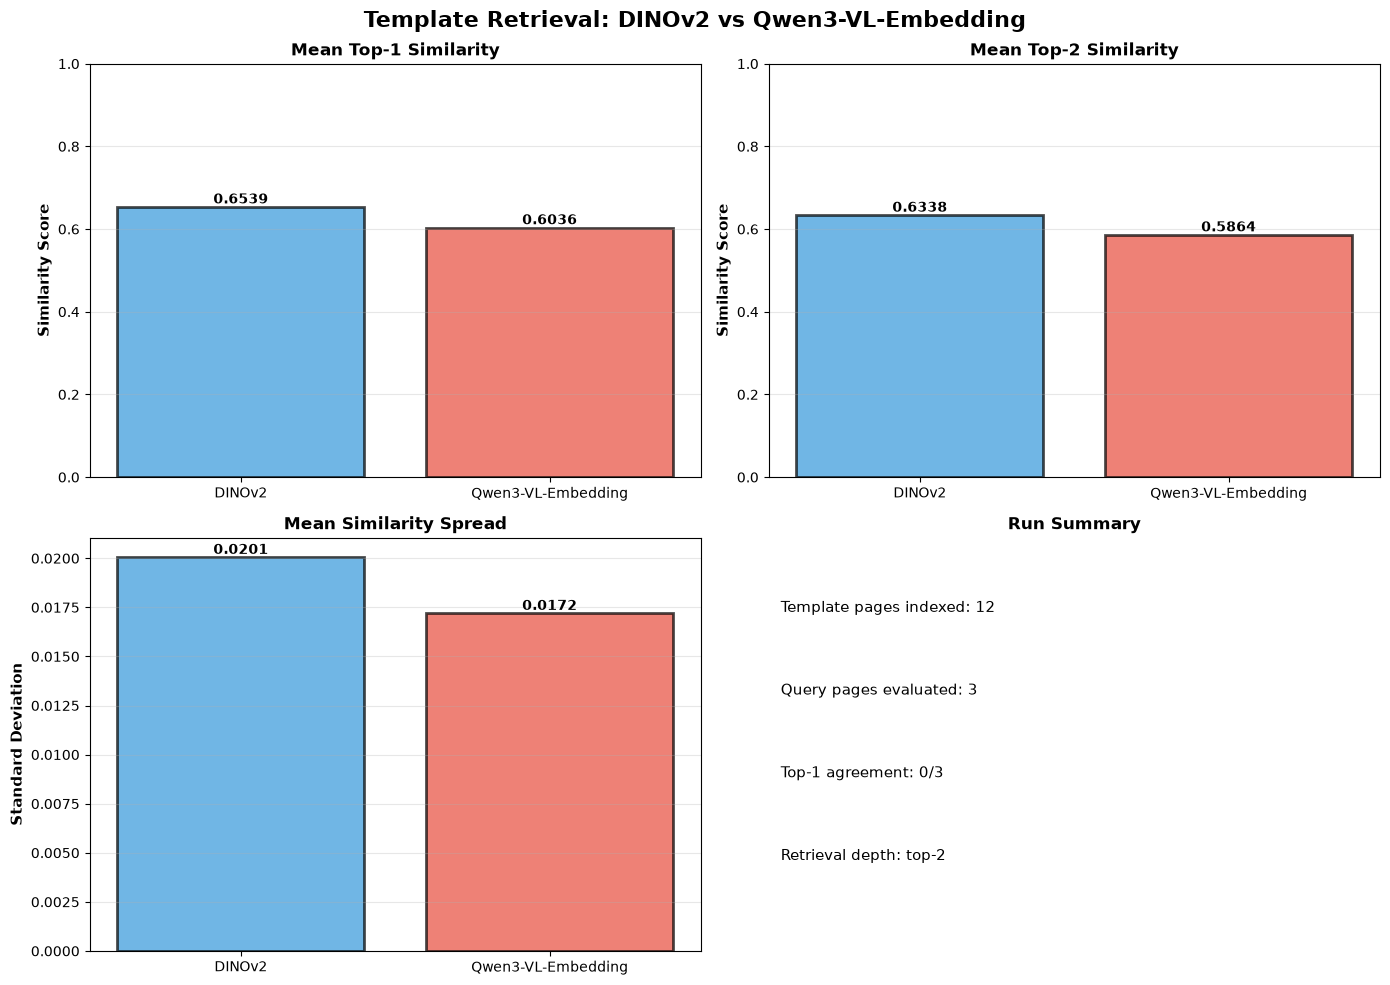


✓ Visualization saved as 'retrieval_quality_comparison.png'


In [33]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Template Retrieval: DINOv2 vs Qwen3-VL-Embedding', fontsize=16, fontweight='bold')

models = ['DINOv2', 'Qwen3-VL-Embedding']
top1_sims = [metrics['dinov2']['mean_top1_similarity'], metrics['qwen']['mean_top1_similarity']]
top2_sims = [metrics['dinov2']['mean_top2_similarity'], metrics['qwen']['mean_top2_similarity']]
spreads = [metrics['dinov2']['mean_similarity_spread'], metrics['qwen']['mean_similarity_spread']]

ax1 = axes[0, 0]
bars1 = ax1.bar(models, top1_sims, color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Similarity Score', fontsize=11, fontweight='bold')
ax1.set_title('Mean Top-1 Similarity', fontsize=12, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, top1_sims):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

ax2 = axes[0, 1]
bars2 = ax2.bar(models, top2_sims, color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('Similarity Score', fontsize=11, fontweight='bold')
ax2.set_title('Mean Top-2 Similarity', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, top2_sims):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

ax3 = axes[1, 0]
bars3 = ax3.bar(models, spreads, color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=2)
ax3.set_ylabel('Standard Deviation', fontsize=11, fontweight='bold')
ax3.set_title('Mean Similarity Spread', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for bar, val in zip(bars3, spreads):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

ax4 = axes[1, 1]
ax4.axis('off')
ax4.set_title('Run Summary', fontsize=12, fontweight='bold')
ax4.text(0.02, 0.82, f'Template pages indexed: {len(template_records)}', fontsize=11)
ax4.text(0.02, 0.62, f'Query pages evaluated: {num_queries}', fontsize=11)
ax4.text(0.02, 0.42, f"Top-1 agreement: {metrics['top1_agreement_count']}/{num_queries}", fontsize=11)
ax4.text(0.02, 0.22, 'Retrieval depth: top-2', fontsize=11)

plt.tight_layout()
plt.savefig('retrieval_quality_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'retrieval_quality_comparison.png'")

## Summary & Conclusions

In [34]:
# Generate summary report
summary_report = f"""
{'='*100}
TEMPLATE RETRIEVAL TEST REPORT
{'='*100}

TEST CONFIGURATION:
  - Template pages indexed: {len(template_records)}
  - Query pages evaluated: {num_queries}
  - Retrieval depth: top-2
  - Distance metric: cosine
  - ChromaDB collections: Separate for each model
  - Device: {device}

KEY FINDINGS:
{'='*100}

1. TOP-1 RETRIEVAL SCORE:
   - DINOv2 (Image-only): {metrics['dinov2']['mean_top1_similarity']:.6f}
   - Qwen3-VL-Embedding (Multimodal): {metrics['qwen']['mean_top1_similarity']:.6f}
   - Winner: {'DINOv2' if metrics['dinov2']['mean_top1_similarity'] > metrics['qwen']['mean_top1_similarity'] else 'Qwen3-VL-Embedding'}

2. TOP-2 AVERAGE RETRIEVAL SCORE:
   - DINOv2 (Image-only): {metrics['dinov2']['mean_top2_similarity']:.6f}
   - Qwen3-VL-Embedding (Multimodal): {metrics['qwen']['mean_top2_similarity']:.6f}
   - Winner: {'DINOv2' if metrics['dinov2']['mean_top2_similarity'] > metrics['qwen']['mean_top2_similarity'] else 'Qwen3-VL-Embedding'}

3. DISCRIMINABILITY (Similarity Spread Across Top-2 Retrieved Templates):
   - DINOv2: {metrics['dinov2']['mean_similarity_spread']:.6f}
   - Qwen3-VL-Embedding: {metrics['qwen']['mean_similarity_spread']:.6f}
   - Winner: {'DINOv2' if metrics['dinov2']['mean_similarity_spread'] > metrics['qwen']['mean_similarity_spread'] else 'Qwen3-VL-Embedding'}

4. TOP-1 AGREEMENT BETWEEN MODELS:
   - Shared top template: {metrics['top1_agreement_count']}/{num_queries} query pages

{'='*100}
RECOMMENDATIONS:
{'='*100}

MODEL SELECTION GUIDANCE:

• DINOv2 (facebook/dinov2-giant):
  - Best for: Pure visual template similarity
  - Strengths: Focused image representation for layout and appearance matching
  - Use case: Template lookup from scanned documents or form pages

• Qwen3-VL-Embedding:
  - Best for: Multimodal retrieval with broader semantic understanding
  - Strengths: Can capture both visual and semantic cues from documents
  - Use case: Template retrieval where both layout and content matter

DEPLOYMENT NOTES:
  - Template PDFs are embedded page-by-page as separate images
  - Query files are loaded from test/ and used individually for retrieval
  - Each retrieval shows the top-2 matching template pages
  - ChromaDB is used with cosine distance for persistent retrieval

{'='*100}
"""

print(summary_report)

with open('retrieval_test_report.txt', 'w') as f:
    f.write(summary_report)

print("\n✓ Report saved as 'retrieval_test_report.txt'")


TEMPLATE RETRIEVAL TEST REPORT

TEST CONFIGURATION:
  - Template pages indexed: 12
  - Query pages evaluated: 3
  - Retrieval depth: top-2
  - Distance metric: cosine
  - ChromaDB collections: Separate for each model
  - Device: cuda

KEY FINDINGS:

1. TOP-1 RETRIEVAL SCORE:
   - DINOv2 (Image-only): 0.653888
   - Qwen3-VL-Embedding (Multimodal): 0.603575
   - Winner: DINOv2

2. TOP-2 AVERAGE RETRIEVAL SCORE:
   - DINOv2 (Image-only): 0.633834
   - Qwen3-VL-Embedding (Multimodal): 0.586374
   - Winner: DINOv2

3. DISCRIMINABILITY (Similarity Spread Across Top-2 Retrieved Templates):
   - DINOv2: 0.020055
   - Qwen3-VL-Embedding: 0.017202
   - Winner: DINOv2

4. TOP-1 AGREEMENT BETWEEN MODELS:
   - Shared top template: 0/3 query pages

RECOMMENDATIONS:

MODEL SELECTION GUIDANCE:

• DINOv2 (facebook/dinov2-giant):
  - Best for: Pure visual template similarity
  - Strengths: Focused image representation for layout and appearance matching
  - Use case: Template lookup from scanned documen

## 8. A/B Retrieval Upgrade: Baseline vs Preprocess vs Hybrid (Image + OCR)

This section adds a side-by-side comparison layer on top of the existing pipeline.

Modes:
- `baseline`: original image embeddings
- `preprocess`: normalized grayscale + resize + contrast
- `hybrid`: weighted fusion of image similarity and OCR-text similarity

Primary metric:
- `Recall@2` using a manual relevance map (you can edit it per query).

In [58]:
!pip install pytesseract

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [9]:
# A/B configuration and helper utilities
from PIL import ImageOps, ImageEnhance

OCR_ENGINE = "none"
ocr_reader = None

try:
    import pytesseract
    OCR_ENGINE = "pytesseract"
except Exception:
    pytesseract = None

if OCR_ENGINE == "none":
    try:
        from paddleocr import PaddleOCR
        ocr_reader = PaddleOCR()
        OCR_ENGINE = "paddleocr"
    except Exception:
        ocr_reader = None

OCR_AVAILABLE = OCR_ENGINE != "none"

AB_MODES = ["baseline", "preprocess", "hybrid"]
HYBRID_ALPHA = 0.7  # image weight in hybrid fusion
TOP_K = 2

# Manual relevance map: query_key -> list of acceptable template keys.
# key format: "file_name|page_number"
manual_relevance_map = {
    # "image copy.png|1": ["Egypt- CoO Templates.pdf|6", "Egypt- CoO Templates.pdf|8"],
    # "image.png|1": ["Egypt- CoO Templates.pdf|9", "Egypt- CoO Templates.pdf|10"],
}


def to_key(file_name: str, page_number: int) -> str:
    return f"{file_name}|{page_number}"


def preprocess_image(image: Image.Image, target_size=(896, 896)) -> Image.Image:
    """Normalize scan appearance to reduce lighting/tint variance for layout matching."""
    gray = ImageOps.grayscale(image)
    enhanced = ImageEnhance.Contrast(gray).enhance(1.25)
    return ImageOps.fit(enhanced.convert("RGB"), target_size, method=Image.Resampling.LANCZOS)


def cosine_sim(vec_a: np.ndarray, vec_b: np.ndarray) -> float:
    denom = float(np.linalg.norm(vec_a) * np.linalg.norm(vec_b))
    if denom == 0.0:
        return 0.0
    return float(np.dot(vec_a, vec_b) / denom)


def extract_text(image: Image.Image) -> str:
    if OCR_ENGINE == "pytesseract" and pytesseract is not None:
        try:
            text = pytesseract.image_to_string(image)
            return " ".join(text.split())
        except Exception:
            return ""

    if OCR_ENGINE == "paddleocr" and ocr_reader is not None:
        try:
            ocr_result = ocr_reader.predict(np.array(image))
            chunks = []
            for page in ocr_result:
                rec_texts = page.get("rec_texts", []) if isinstance(page, dict) else []
                chunks.extend(rec_texts)
            return " ".join(" ".join(chunks).split())
        except Exception:
            return ""

    return ""


def text_similarity(query_text: str, template_text: str) -> float:
    if qwen_model is not None and query_text and template_text:
        try:
            qv = qwen_model.encode(query_text)
            tv = qwen_model.encode(template_text)
            return cosine_sim(np.asarray(qv), np.asarray(tv))
        except Exception:
            pass

    # Fallback lexical overlap when text embedding or OCR is unavailable.
    q_tokens = set(query_text.lower().split())
    t_tokens = set(template_text.lower().split())
    if not q_tokens or not t_tokens:
        return 0.0
    inter = len(q_tokens.intersection(t_tokens))
    union = len(q_tokens.union(t_tokens))
    return float(inter / union) if union else 0.0


def get_mode_image(image: Image.Image, mode: str) -> Image.Image:
    return preprocess_image(image) if mode in {"preprocess", "hybrid"} else image


print(f"OCR available: {OCR_AVAILABLE}")
print(f"OCR engine: {OCR_ENGINE}")
print(f"Modes: {AB_MODES}")

OCR available: True
OCR engine: pytesseract
Modes: ['baseline', 'preprocess', 'hybrid']


In [10]:
# Build mode-aware embeddings and OCR text caches

def embed_image_dinov2(image: Image.Image) -> np.ndarray:
    with torch.no_grad():
        inputs = dinov2_processor(images=image, return_tensors="pt").to(device)
        outputs = dinov2_model(**inputs)
        return outputs.last_hidden_state[:, 0, :].cpu().numpy().flatten()


def embed_image_qwen(image: Image.Image) -> np.ndarray:
    return np.asarray(qwen_model.encode(image))


template_by_id = {record["id"]: record for record in template_records}
query_by_id = {record["id"]: record for record in query_records}

mode_template_embeddings = {
    "dinov2": {mode: {} for mode in AB_MODES},
    "qwen": {mode: {} for mode in AB_MODES},
}
mode_query_embeddings = {
    "dinov2": {mode: {} for mode in AB_MODES},
    "qwen": {mode: {} for mode in AB_MODES},
}

template_texts = {}
query_texts = {}

print("\nBuilding template embeddings/text caches...")
for rec in template_records:
    base_img = rec["image"]
    for mode in AB_MODES:
        mode_img = get_mode_image(base_img, mode)
        if dinov2_model is not None:
            mode_template_embeddings["dinov2"][mode][rec["id"]] = embed_image_dinov2(mode_img)
        if qwen_model is not None:
            mode_template_embeddings["qwen"][mode][rec["id"]] = embed_image_qwen(mode_img)

    if "hybrid" in AB_MODES:
        template_texts[rec["id"]] = extract_text(get_mode_image(base_img, "hybrid"))

print("Building query embeddings/text caches...")
for rec in query_records:
    base_img = rec["image"]
    for mode in AB_MODES:
        mode_img = get_mode_image(base_img, mode)
        if dinov2_model is not None:
            mode_query_embeddings["dinov2"][mode][rec["id"]] = embed_image_dinov2(mode_img)
        if qwen_model is not None:
            mode_query_embeddings["qwen"][mode][rec["id"]] = embed_image_qwen(mode_img)

    if "hybrid" in AB_MODES:
        query_texts[rec["id"]] = extract_text(get_mode_image(base_img, "hybrid"))

print("Done building embeddings and text caches.")


Building template embeddings/text caches...
Building query embeddings/text caches...
Done building embeddings and text caches.


In [11]:
# Run A/B retrieval across modes for both models

def retrieve_topk_for_model_mode(query_id: str, model_name: str, mode: str, top_k: int = 2) -> List[Dict[str, Any]]:
    q_emb = mode_query_embeddings[model_name][mode][query_id]
    scored = []

    for t_id, t_emb in mode_template_embeddings[model_name][mode].items():
        image_sim = cosine_sim(q_emb, t_emb)
        final_sim = image_sim

        if mode == "hybrid":
            txt_sim = text_similarity(query_texts.get(query_id, ""), template_texts.get(t_id, ""))
            final_sim = HYBRID_ALPHA * image_sim + (1.0 - HYBRID_ALPHA) * txt_sim

        t_meta = template_by_id[t_id]
        scored.append({
            "template_id": t_id,
            "file_name": t_meta["file_name"],
            "page_number": t_meta["page_number"],
            "similarity": float(final_sim),
            "image_similarity": float(image_sim),
        })

    scored.sort(key=lambda x: x["similarity"], reverse=True)
    return scored[:top_k]


def run_ab_retrieval(top_k: int = 2) -> Dict[str, Any]:
    results = {}

    for q in query_records:
        q_id = q["id"]
        results[q_id] = {
            "query": q,
            "dinov2": {},
            "qwen": {},
        }

        if dinov2_model is not None:
            for mode in AB_MODES:
                results[q_id]["dinov2"][mode] = retrieve_topk_for_model_mode(q_id, "dinov2", mode, top_k=top_k)

        if qwen_model is not None:
            for mode in AB_MODES:
                results[q_id]["qwen"][mode] = retrieve_topk_for_model_mode(q_id, "qwen", mode, top_k=top_k)

    return results


ab_results = run_ab_retrieval(top_k=TOP_K)
print(f"A/B retrieval complete for {len(ab_results)} query pages.")

# Print compact per-query comparison
for q_id, payload in ab_results.items():
    q = payload["query"]
    q_key = to_key(q["file_name"], q["page_number"])
    print("\n" + "=" * 100)
    print(f"Query: {q_key}")

    for model_name in ["dinov2", "qwen"]:
        if not payload[model_name]:
            continue
        print(f"\n{model_name.upper()}:")
        for mode in AB_MODES:
            top = payload[model_name].get(mode, [])
            if top:
                t = top[0]
                print(f"  {mode:<10} -> top1: {to_key(t['file_name'], t['page_number'])} | sim={t['similarity']:.4f}")

A/B retrieval complete for 3 query pages.

Query: image copy2.png|1

DINOV2:
  baseline   -> top1: Egypt- CoO Templates.pdf|6 | sim=0.7332
  preprocess -> top1: Egypt- CoO Templates.pdf|6 | sim=0.7364
  hybrid     -> top1: Egypt- CoO Templates.pdf|6 | sim=0.5155

QWEN:
  baseline   -> top1: Egypt- CoO Templates.pdf|6 | sim=0.6985
  preprocess -> top1: CoO UN template.png|1 | sim=0.6277
  hybrid     -> top1: CoO UN template.png|1 | sim=0.4394

Query: image.png|1

DINOV2:
  baseline   -> top1: Egypt- CoO Templates.pdf|7 | sim=0.6726
  preprocess -> top1: Egypt- CoO Templates.pdf|6 | sim=0.7486
  hybrid     -> top1: Egypt- CoO Templates.pdf|6 | sim=0.5240

QWEN:
  baseline   -> top1: Egypt- CoO Templates.pdf|7 | sim=0.7964
  preprocess -> top1: Egypt- CoO Templates.pdf|7 | sim=0.6717
  hybrid     -> top1: Egypt- CoO Templates.pdf|7 | sim=0.4702

Query: image1.png|1

DINOV2:
  baseline   -> top1: Egypt- CoO Templates.pdf|10 | sim=0.7421
  preprocess -> top1: Egypt- CoO Templates.pdf|10 | s

In [12]:
# Evaluate Recall@2 and improvement deltas

def hit_at_k(predictions: List[Dict[str, Any]], relevant_keys: set) -> int:
    for item in predictions:
        if to_key(item["file_name"], item["page_number"]) in relevant_keys:
            return 1
    return 0


def build_proxy_relevance_if_empty(results: Dict[str, Any]) -> Dict[str, List[str]]:
    """Fallback proxy labels: uses baseline top-2 union from both models.
    Replace with true manual labels for real Recall@2.
    """
    proxy = {}
    for q_id, payload in results.items():
        q = payload["query"]
        q_key = to_key(q["file_name"], q["page_number"])
        if q_key in manual_relevance_map:
            proxy[q_key] = manual_relevance_map[q_key]
            continue

        keys = []
        for model_name in ["dinov2", "qwen"]:
            baseline_preds = payload.get(model_name, {}).get("baseline", [])
            for pred in baseline_preds:
                keys.append(to_key(pred["file_name"], pred["page_number"]))
        proxy[q_key] = sorted(set(keys))[:2]
    return proxy


relevance_map = build_proxy_relevance_if_empty(ab_results)

rows = []
for model_name in ["dinov2", "qwen"]:
    if not any(ab_results[q].get(model_name) for q in ab_results):
        continue

    for mode in AB_MODES:
        hits = []
        top1_sims = []
        gaps = []
        for q_id, payload in ab_results.items():
            q = payload["query"]
            q_key = to_key(q["file_name"], q["page_number"])
            relevant = set(relevance_map.get(q_key, []))
            preds = payload[model_name].get(mode, [])
            if not preds:
                continue

            hits.append(hit_at_k(preds, relevant))
            top1_sims.append(preds[0]["similarity"])
            if len(preds) > 1:
                gaps.append(preds[0]["similarity"] - preds[1]["similarity"])

        rows.append({
            "model": model_name,
            "mode": mode,
            "recall_at_2": float(np.mean(hits)) if hits else 0.0,
            "mean_top1_similarity": float(np.mean(top1_sims)) if top1_sims else 0.0,
            "mean_confidence_gap": float(np.mean(gaps)) if gaps else 0.0,
        })

import pandas as pd
ab_metrics_df = pd.DataFrame(rows)
print("\nA/B metrics (Recall@2 primary):")
print(ab_metrics_df.to_string(index=False))

# Win/loss vs baseline using top-1 similarity
win_rows = []
for model_name in ["dinov2", "qwen"]:
    if not any(ab_results[q].get(model_name) for q in ab_results):
        continue

    for mode in ["preprocess", "hybrid"]:
        wins = 0
        losses = 0
        ties = 0
        for q_id, payload in ab_results.items():
            baseline = payload[model_name].get("baseline", [])
            improved = payload[model_name].get(mode, [])
            if not baseline or not improved:
                continue
            b = baseline[0]["similarity"]
            i = improved[0]["similarity"]
            if i > b:
                wins += 1
            elif i < b:
                losses += 1
            else:
                ties += 1

        win_rows.append({
            "model": model_name,
            "comparison": f"{mode} vs baseline",
            "wins": wins,
            "losses": losses,
            "ties": ties,
        })

win_df = pd.DataFrame(win_rows)
print("\nTop-1 similarity win/loss summary:")
print(win_df.to_string(index=False))


A/B metrics (Recall@2 primary):
 model       mode  recall_at_2  mean_top1_similarity  mean_confidence_gap
dinov2   baseline     1.000000              0.715982             0.018001
dinov2 preprocess     1.000000              0.761243             0.022858
dinov2     hybrid     1.000000              0.532870             0.016000
  qwen   baseline     1.000000              0.731571             0.036160
  qwen preprocess     0.666667              0.645568             0.013520
  qwen     hybrid     0.666667              0.451898             0.009464

Top-1 similarity win/loss summary:
 model             comparison  wins  losses  ties
dinov2 preprocess vs baseline     3       0     0
dinov2     hybrid vs baseline     0       3     0
  qwen preprocess vs baseline     0       3     0
  qwen     hybrid vs baseline     0       3     0


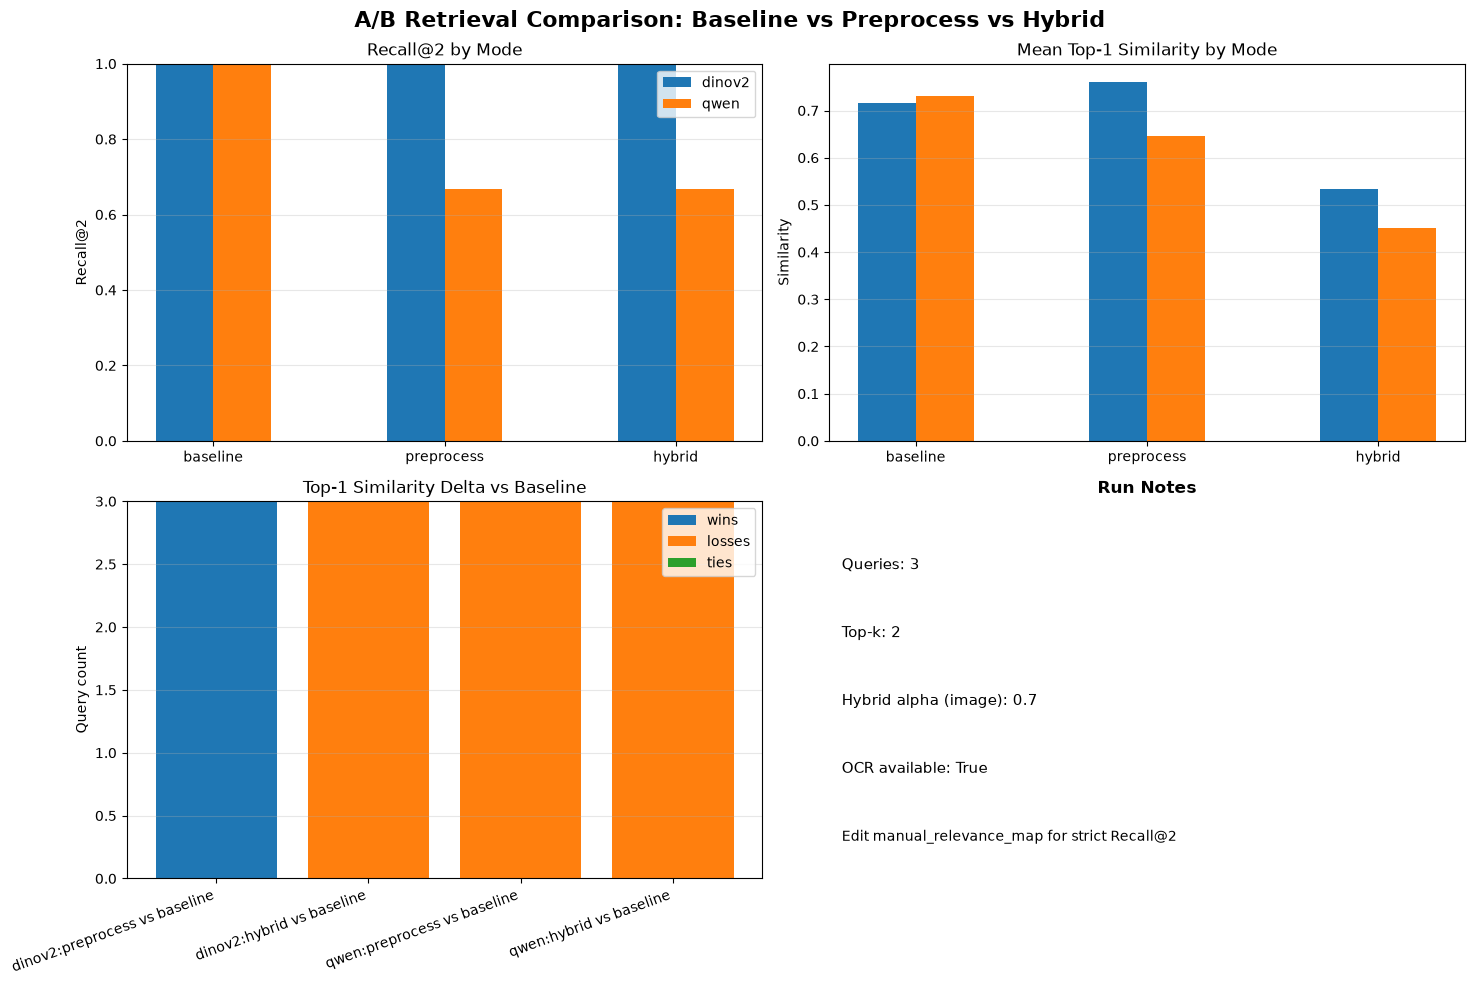


Saved figure: retrieval_ab_comparison.png


In [ ]:
from paddleocr import PaddleOCR

OCR_ENGINE = "none"
ocr_reader = None

try:
    ocr_reader = PaddleOCR(
        use_doc_orientation_classify=False,
        use_doc_unwarping=False,
        use_textline_orientation=False,
        enable_hpi=True,
    )
    OCR_ENGINE = "paddleocr"
except Exception as e:
    print(f"PaddleOCR init failed: {e}")
    ocr_reader = None

print(f"OCR engine: {OCR_ENGINE}")


def extract_text(image: Image.Image) -> str:
    if OCR_ENGINE == "paddleocr" and ocr_reader is not None:
        try:
            ocr_result = ocr_reader.predict(np.array(image))
            chunks = []
            for page in ocr_result:
                rec_texts = page.get("rec_texts", []) if isinstance(page, dict) else []
                chunks.extend(rec_texts)
            return " ".join(" ".join(chunks).split())
        except Exception:
            return ""

    return ""


OCR_AVAILABLE = OCR_ENGINE != "none"

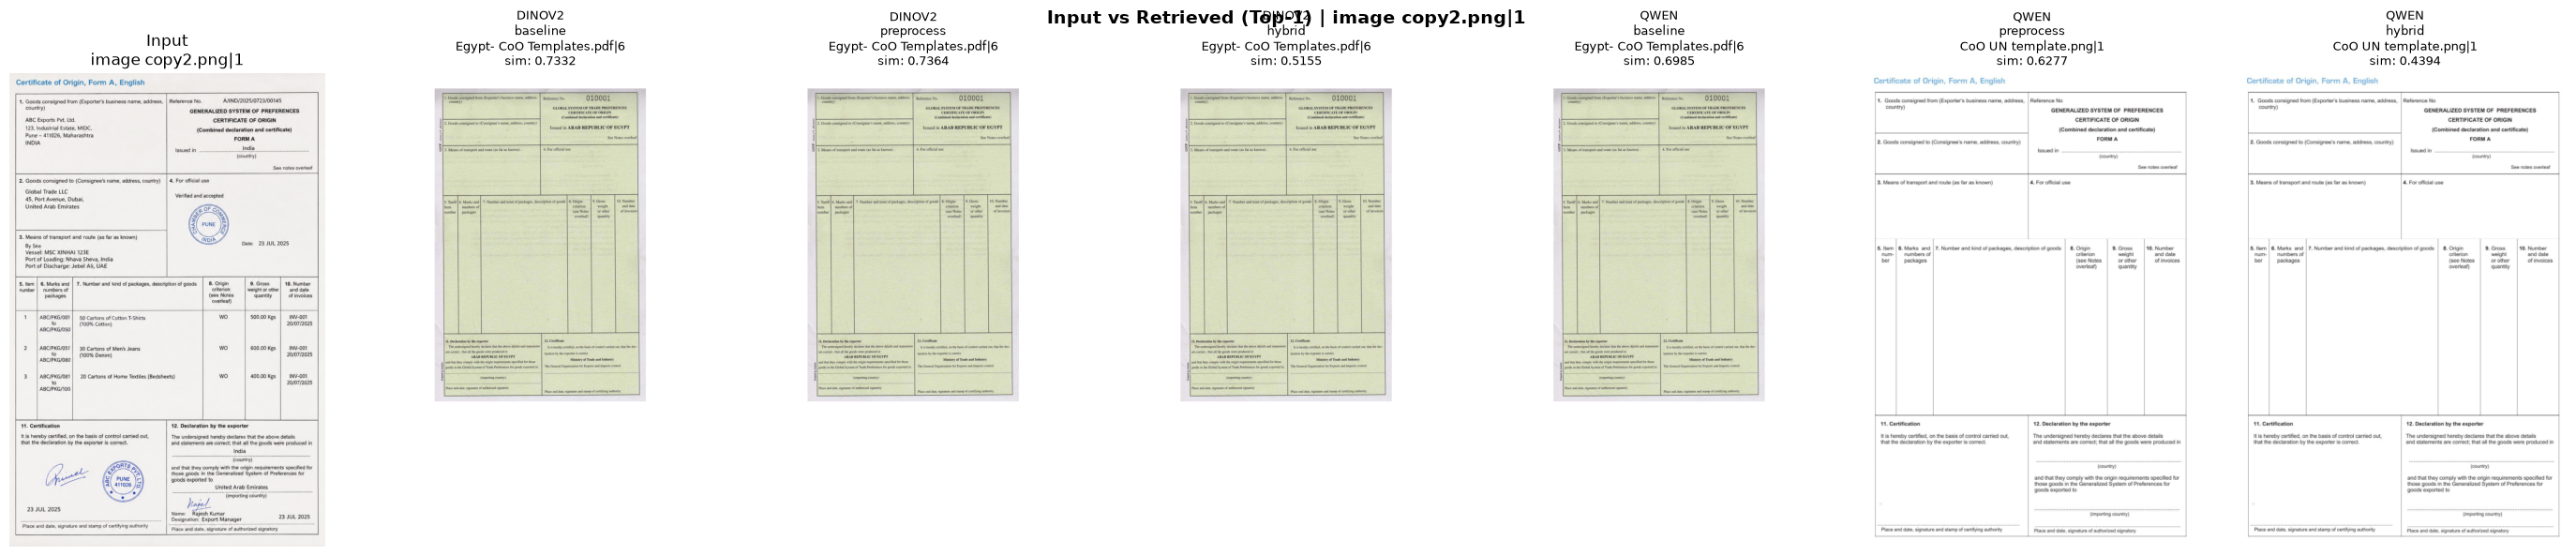

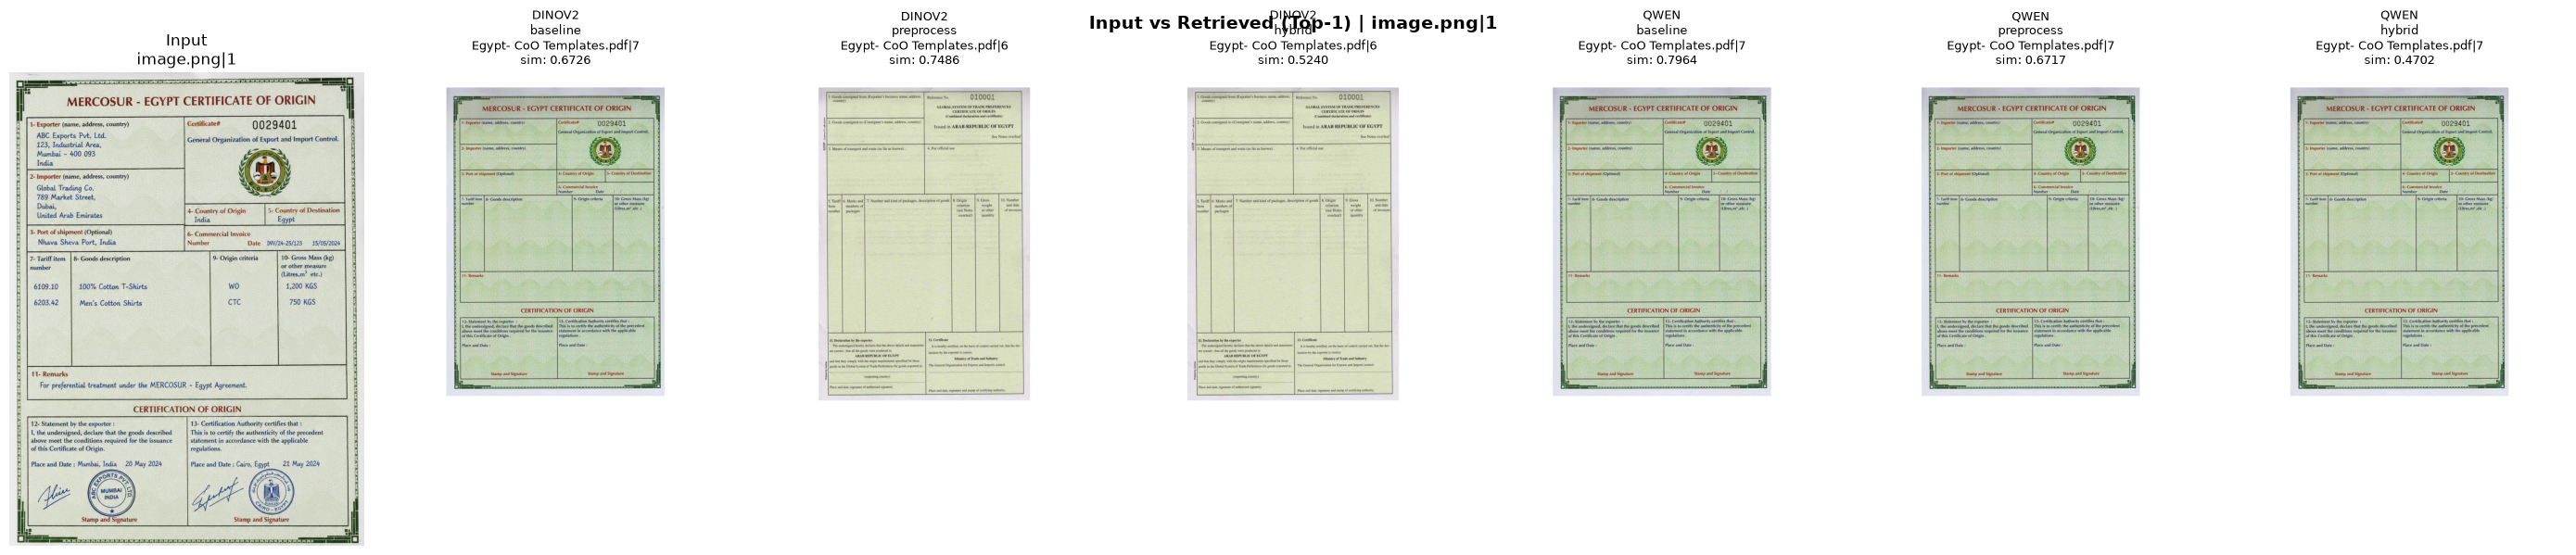

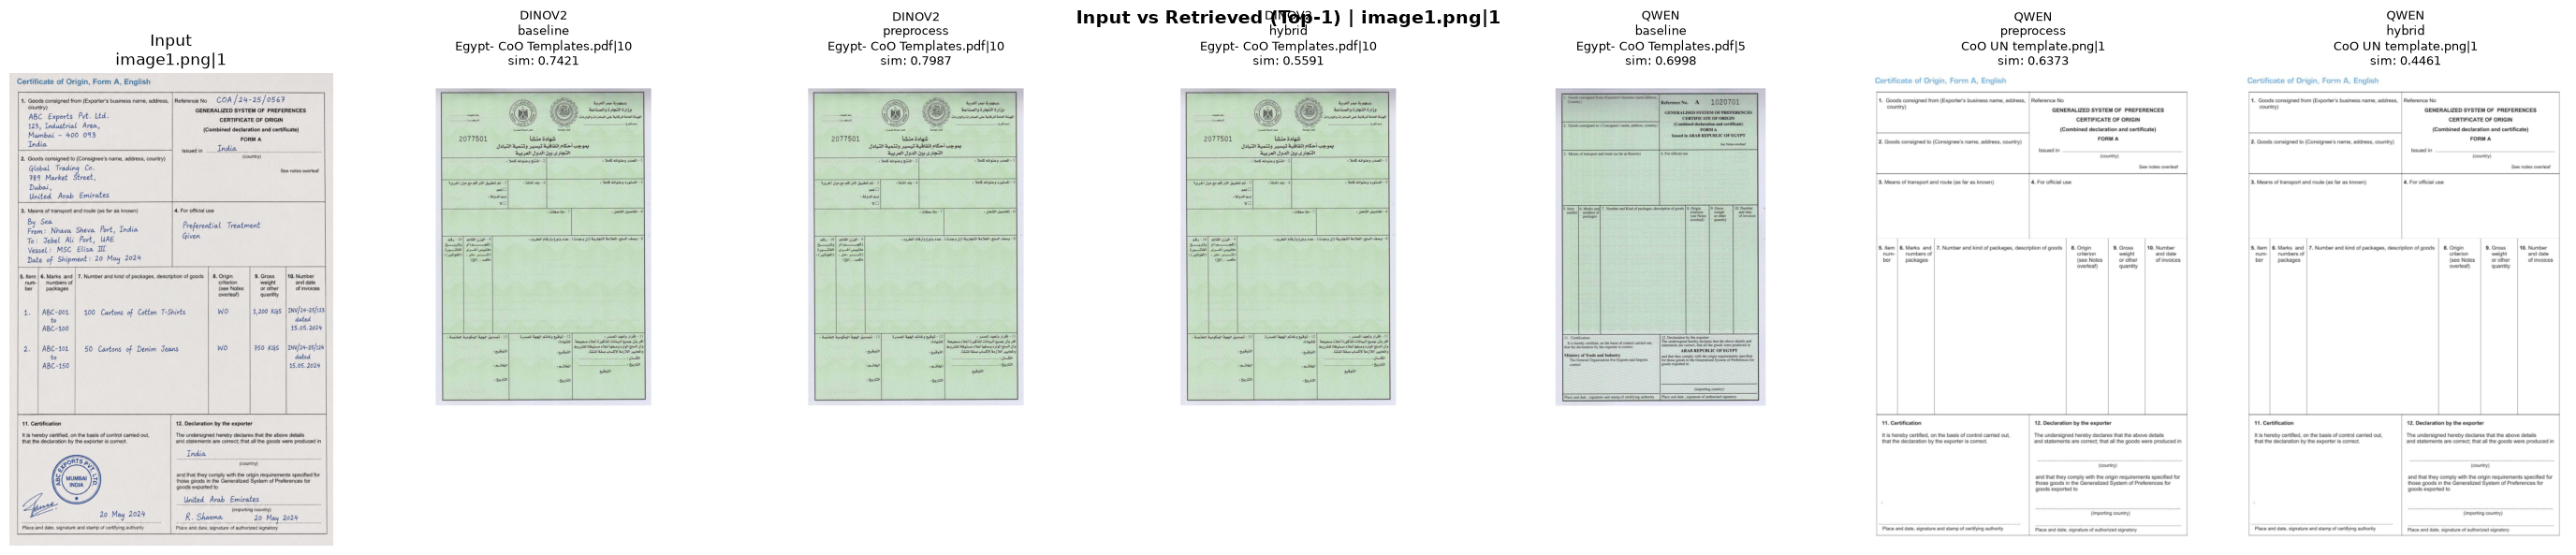

Done: displayed input and retrieved images for all test queries.


In [14]:
# Visual gallery: test input vs retrieved template images (top-1 per mode/model)

modes_to_show = ["baseline", "preprocess", "hybrid"]
models_to_show = ["dinov2", "qwen"]

for query_id, payload in ab_results.items():
    query_meta = payload["query"]
    query_img = query_meta["image"]
    query_label = to_key(query_meta["file_name"], query_meta["page_number"])

    cols = 1 + len(models_to_show) * len(modes_to_show)
    fig, axes = plt.subplots(1, cols, figsize=(4 * cols, 6))
    fig.suptitle(f"Input vs Retrieved (Top-1) | {query_label}", fontsize=14, fontweight="bold")

    # Input image
    axes[0].imshow(query_img)
    axes[0].set_title(f"Input\n{query_label}")
    axes[0].axis("off")

    col_idx = 1
    for model_name in models_to_show:
        model_results = payload.get(model_name, {})
        for mode in modes_to_show:
            ax = axes[col_idx]
            preds = model_results.get(mode, [])
            if preds:
                top1 = preds[0]
                template_key = to_key(top1["file_name"], top1["page_number"])

                # Locate image from template records
                top_record = None
                for record in template_records:
                    if record["file_name"] == top1["file_name"] and record["page_number"] == top1["page_number"]:
                        top_record = record
                        break

                if top_record is not None:
                    ax.imshow(top_record["image"])
                    ax.set_title(
                        f"{model_name.upper()}\n{mode}\n{template_key}\nsim: {top1['similarity']:.4f}",
                        fontsize=9,
                    )
                else:
                    ax.text(0.5, 0.5, "Image missing", ha="center", va="center")
                    ax.set_title(f"{model_name.upper()}\n{mode}\n{template_key}", fontsize=9)
            else:
                ax.text(0.5, 0.5, "No result", ha="center", va="center")
                ax.set_title(f"{model_name.upper()}\n{mode}", fontsize=9)

            ax.axis("off")
            col_idx += 1

    plt.tight_layout()
    plt.show()

print("Done: displayed input and retrieved images for all test queries.")